# Model Testing (CPU)

Offline inference on dataset images with wheel output preview.

This notebook loads a trained model on CPU, runs predictions on dataset images,
and shows predicted target points plus the computed left/right wheel values.
No JetBot hardware is needed.

In [1]:
import glob
import math
import os
import random

import numpy as np
import pandas as pd
import PIL.Image
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms

DATASET_NAME = 'dataset_labeled_2'
DATASET_DIR = f'datasets/{DATASET_NAME}'
MODEL_PATH = f'models/{DATASET_NAME}/model_to_import.pth'
DEVICE = torch.device('cpu')

# Controls that affect wheel output
SPEED_GAIN = 0.2
STEERING_GAIN = 0.2
STEERING_BIAS = 0.0
STEERING_DGAIN = 0.0

C:\Users\jakub\AppData\Local\Temp\ipykernel_8032\2087297127.py:7: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
image_paths = sorted(glob.glob(os.path.join(DATASET_DIR, '*.jpg')))
if not image_paths:
    raise FileNotFoundError(f'No .jpg images found in {DATASET_DIR}')

labels_csv = os.path.join(DATASET_DIR, 'labels.csv')
labels_map = {}
if os.path.exists(labels_csv):
    df_labels = pd.read_csv(labels_csv)
    labels_map = {
        os.path.basename(r['image_path']): (float(r['x_norm']), float(r['y_norm']))
        for _, r in df_labels.iterrows()
    }

print(f'Images: {len(image_paths)}')
print(f'Labels: {len(labels_map)}')

Images: 401
Labels: 401


In [3]:
model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
state = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

print('Model loaded on', DEVICE)

Model loaded on cpu


c:\Users\jakub\Desktop\robotics-project-main\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\jakub\Desktop\robotics-project-main\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [19]:

mean = torch.tensor([0.485, 0.456, 0.406])
std  = torch.tensor([0.229, 0.224, 0.225])

def preprocess_live_demo_cpu(image):
    # dokładnie jak live_demo, tylko bez cuda i half

    if isinstance(image, PIL.Image.Image):
        image = np.array(image)

    image = PIL.Image.fromarray(image)

    tensor = transforms.functional.to_tensor(image)

    tensor.sub_(mean[:, None, None])
    tensor.div_(std[:, None, None])

    return tensor.unsqueeze(0)

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def predict_xy(image):
    tensor = preprocess_live_demo_cpu(image)
    with torch.no_grad():
        xy = model(tensor).detach().cpu().numpy().flatten()
    return xy


def compute_wheel_output(
    xy,
    speed_gain=SPEED_GAIN,
    steering_gain=STEERING_GAIN,
    steering_bias=STEERING_BIAS,
    steering_dgain=STEERING_DGAIN,
    angle_last=0.0,
):
    x = xy[0] - 0.5
    y = 1.0 - xy[1]
    angle = np.arctan2(x, y)

    pid = angle * steering_gain + (angle - angle_last) * steering_dgain
    steering = pid + steering_bias

    # steering = speed_gain * steering_gain * angle + steering_bias
    
    left  = float(np.clip(speed_gain + steering, 0.0, 1.0))
    right = float(np.clip(speed_gain - steering, 0.0, 1.0))
    return {
        'x':       float(xy[0]),
        'y':       float(xy[1]),
        'angle':   float(angle),
        'steering': float(steering),
        'left':    left,
        'right':   right,
    }

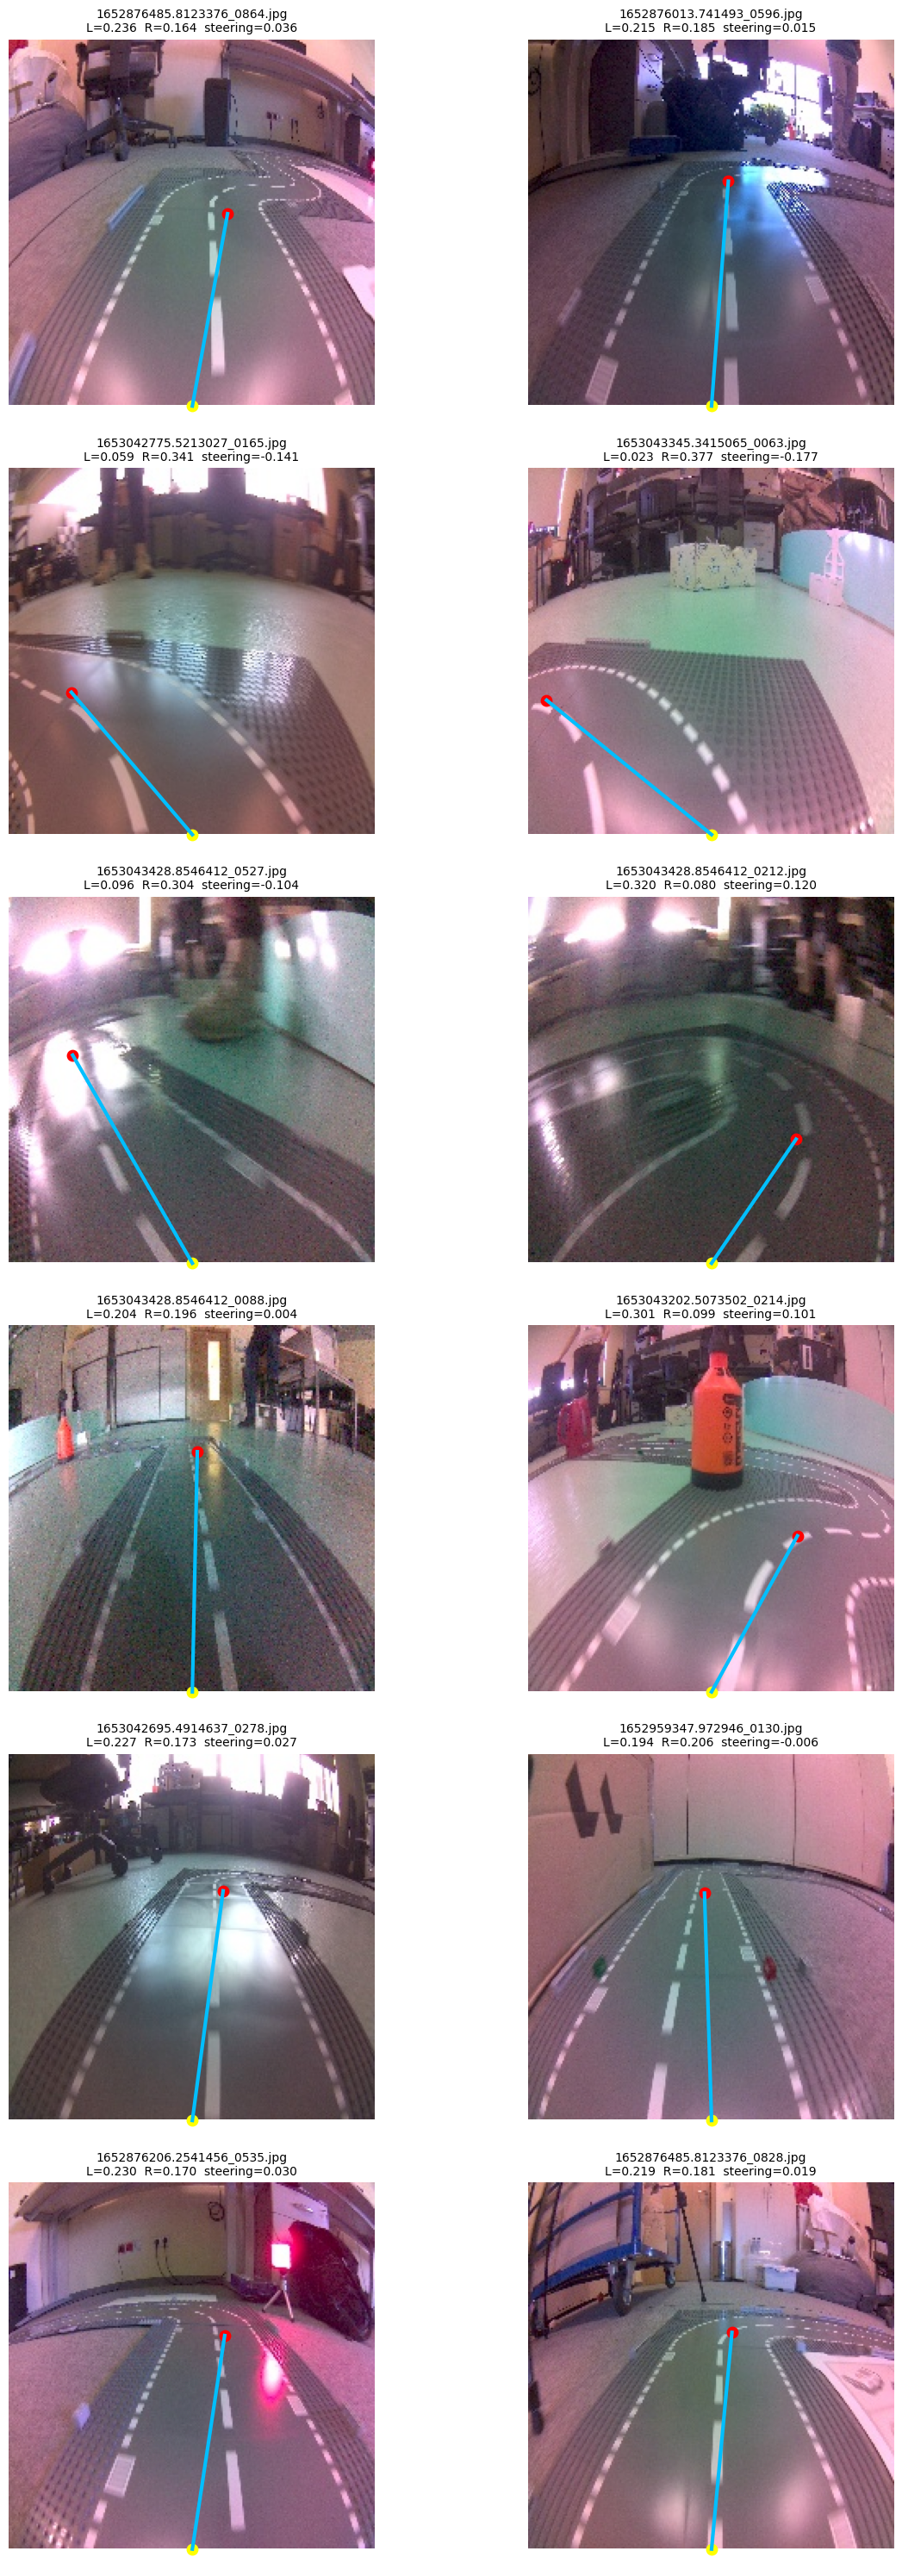

In [28]:
def show_sample_predictions(num_samples=4, seed=423):
    random.seed(seed)
    sample_paths = random.sample(image_paths, min(num_samples, len(image_paths)))

    cols = 2
    rows = math.ceil(len(sample_paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, img_path in zip(axes, sample_paths):
        image = PIL.Image.open(img_path).convert('RGB')
        width, height = image.size
        xy = predict_xy(image)
        output = compute_wheel_output(xy)

        pred_x = np.clip(output['x'], 0.0, 1.0) * width
        pred_y = np.clip(output['y'], 0.0, 1.0) * height
        center_x = width / 2
        center_y = height

        ax.imshow(image)
        ax.plot([center_x, pred_x], [center_y, pred_y], color='deepskyblue', linewidth=3)
        ax.scatter([pred_x], [pred_y], c='red', s=80)
        ax.scatter([center_x], [center_y], c='yellow', s=80)
        ax.set_title(
            f"{os.path.basename(img_path)}\n"
            f"L={output['left']:.3f}  R={output['right']:.3f}  steering={output['steering']:.3f}",
            fontsize=10,
        )
        ax.axis('off')

    for ax in axes[len(sample_paths):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_sample_predictions(num_samples=12)

In [ ]:
import time


def benchmark_inference(num_images=20, repeats=10, seed=123):
    random.seed(seed)
    sample_paths = random.sample(image_paths, min(num_images, len(image_paths)))

    rows = []
    with torch.no_grad():
        for img_path in sample_paths:
            image = PIL.Image.open(img_path).convert('RGB')

            start = time.perf_counter()
            xy = None
            for _ in range(repeats):
                xy = predict_xy(image)

            output = compute_wheel_output(xy)

            elapsed = (time.perf_counter() - start) / repeats
            
            rows.append({
                'image': os.path.basename(img_path),
                'time_ms': elapsed * 1000.0,
                'x': output['x'],
                'y': output['y'],
                'steering': output['steering'],
                'left': output['left'],
                'right': output['right'],
            })

    results = pd.DataFrame(rows).sort_values('time_ms', ascending=False).reset_index(drop=True)
    print(f"Average inference time: {results['time_ms'].mean():.2f} ms")
    print(f"Min inference time: {results['time_ms'].min():.2f} ms")
    print(f"Max inference time: {results['time_ms'].max():.2f} ms")
    return results


benchmark_results = benchmark_inference(num_images=10, repeats=20)
benchmark_results

AttributeError: 'Tensor' object has no attribute '__array_interface__'

In [ ]:
import numpy as np
import random
import PIL.Image

random.seed(42)
sample_paths = random.sample(image_paths, min(8, len(image_paths)))

print(f"{'obraz':<30} {'x':>6} {'y':>6} {'angle':>8} {'steering':>10} {'left':>7} {'right':>7}")
print("-" * 80)

for img_path in sample_paths:
    image = PIL.Image.open(img_path).convert('RGB')
    xy = predict_xy(image)
    
    x_raw = xy[0]
    y_raw = xy[1]
    
    x = x_raw - 0.5
    y = (1.0 - y_raw)        # zamiast 0.5 - y_raw — y zawsze dodatnie [0..1]
    angle = np.arctan2(x, y)
    pid = angle * STEERING_GAIN + 0.0  # dgain=0
    steering = pid + STEERING_BIAS
    left  = float(np.clip(SPEED_GAIN + steering, 0.0, 1.0))
    right = float(np.clip(SPEED_GAIN - steering, 0.0, 1.0))
    
    print(f"{img_path[-28:]:<30} {x_raw:>6.3f} {y_raw:>6.3f} {angle:>8.3f} {steering:>10.3f} {left:>7.3f} {right:>7.3f}")

obraz                               x      y    angle   steering    left   right
--------------------------------------------------------------------------------
\1653043345.3415065_0076.jpg    0.148  0.618   -1.894     -0.379   0.000   0.579
2\1652876013.741493_0230.jpg    0.965  0.628    1.839      0.368   0.568   0.000
\1652875901.3107166_0041.jpg    0.564  0.410    0.613      0.123   0.323   0.077
\1653043428.8546412_0323.jpg    0.554  0.577    2.536      0.507   0.707   0.000
\1652876485.8123376_0303.jpg    0.559  0.547    2.248      0.450   0.650   0.000
\1652876206.2541456_0875.jpg    0.531  0.312    0.162      0.032   0.232   0.168
\1652876206.2541456_0585.jpg    0.327  0.374   -0.940     -0.188   0.012   0.388
2\1652876013.741493_0436.jpg    0.627  0.371    0.781      0.156   0.356   0.044


# ROBOT TESTING

In [ ]:
import torch
import torchvision
import numpy as np
import PIL.Image
from jetbot import Camera, Robot, bgr8_to_jpeg
import torchvision.transforms as transforms
import ipywidgets
import traitlets
from IPython.display import display

# ── ścieżka do modelu ────────────────────────────────────────────────────────
MODEL_PATH = 'models/dataset_labeled_2/model_to_import.pth'
# ────────────────────────────────────────────────────────────────────────────

# model
model = torchvision.models.resnet18(pretrained=False)
model.fc = torch.nn.Linear(512, 2)
model.load_state_dict(torch.load(MODEL_PATH))
device = torch.device('cuda')
model = model.to(device).eval().half()
print('Model załadowany na', device)

# preprocessing (identyczny z live_demo)
mean = torch.Tensor([0.485, 0.456, 0.406]).cuda().half()
std  = torch.Tensor([0.229, 0.224, 0.225]).cuda().half()

def preprocess(image):
    image = PIL.Image.fromarray(image)
    image = transforms.functional.to_tensor(image).to(device).half()
    image.sub_(mean[:, None, None]).div_(std[:, None, None])
    return image[None, ...]

# kamera
camera = Camera()
image_widget = ipywidgets.Image()
traitlets.dlink((camera, 'value'), (image_widget, 'value'), transform=bgr8_to_jpeg)
display(image_widget)

# robot
robot = Robot()

print('Kamera i robot gotowe')

In [ ]:
import time
import numpy as np
import pandas as pd

# ── parametry (te same co w live_demo) ──────────────────────────────────────
SPEED_GAIN     = 0.15
STEERING_GAIN  = 0.30
STEERING_DGAIN = 0.0
STEERING_BIAS  = 0.0
N_FRAMES       = 30   # ile klatek zmierzyć
# ────────────────────────────────────────────────────────────────────────────

angle_last = 0.0
rows = []
timestamps = []
frames = []

for i in range(N_FRAMES):

    timestamps.append(time.perf_counter())

    # 1. odczyt klatki z kamery
    t0 = time.perf_counter()
    frame = camera.value
    t1 = time.perf_counter()

    # 2. preprocessing
    tensor = preprocess(frame)
    t2 = time.perf_counter()

    # 3. inferencja modelu
    with torch.no_grad():
        xy = model(tensor).detach().float().cpu().numpy().flatten()
    t3 = time.perf_counter()

    # 4. sterowanie (execute)
    x_raw, y_raw = float(xy[0]), float(xy[1])
    output = compute_wheel_output([x_raw, y_raw], angle_last=angle_last)
    angle_last = output['angle']
    left  = output['left']
    right = output['right']
    t4 = time.perf_counter()

    # 5. zapis na silniki
    robot.left_motor.value  = left
    robot.right_motor.value = right
    t5 = time.perf_counter()

    frames.append(frame.copy())
    rows.append({
        'klatka':        i,
        'kamera_ms':     (t1 - t0) * 1000,
        'preprocess_ms': (t2 - t1) * 1000,
        'model_ms':      (t3 - t2) * 1000,
        'execute_ms':    (t4 - t3) * 1000,
        'silniki_ms':    (t5 - t4) * 1000,
        'total_ms':      (t5 - t0) * 1000,
        'x':             x_raw,
        'y':             y_raw,
        'angle':         angle,
        'steering':      steering,
        'left':          left,
        'right':         right,
    })

# zatrzymaj robota po teście
robot.stop()

df = pd.DataFrame(rows)

print("=== ŚREDNIE CZASY ===")
for col in ['kamera_ms', 'preprocess_ms', 'model_ms', 'execute_ms', 'silniki_ms', 'total_ms']:
    print(f"  {col:<16} avg={df[col].mean():6.2f}ms   max={df[col].max():6.2f}ms")

print(f"\n=== FPS (total) ===  avg={1000/df['total_ms'].mean():.1f}  min={1000/df['total_ms'].max():.1f}")

print("\n=== PREDYKCJE + STEROWANIE ===")
print(df[['klatka','x','y','angle','steering','left','right']].to_string(index=False))

print("\n=== ODSTĘPY MIĘDZY KLATKAMI ===")
gaps = [(timestamps[i+1] - timestamps[i]) * 1000 for i in range(len(timestamps) - 1)]
t_start = timestamps[0]
df_gaps = pd.DataFrame({
    'klatka':      range(1, len(gaps) + 1),
    'czas_od_startu_ms': [(timestamps[i] - t_start) * 1000 for i in range(1, len(timestamps))],
    'gap_ms':      gaps,
    'fps_instant': [1000 / g for g in gaps],
})

print(f"  avg gap: {np.mean(gaps):.2f}ms  |  max gap: {np.max(gaps):.2f}ms  |  min gap: {np.min(gaps):.2f}ms")
print(f"  avg FPS: {1000/np.mean(gaps):.1f}  |  min FPS: {1000/np.max(gaps):.1f}")
print()
print(df_gaps.to_string(index=False))

### ZDJECIA TUTAJ POWINNY BYC Z PREDYCKAJMI

In [ ]:
import matplotlib.pyplot as plt
import math

cols = 4
rows = math.ceil(N_FRAMES / cols)
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for i, row in df.iterrows():
    ax = axes[i]
    
    # zdekoduj klatkę z kamery — potrzebujemy zapisanych klatek
    frame = frames[i]
    image = PIL.Image.fromarray(frame)
    width, height = image.size
    
    pred_x = np.clip(row['x'], 0.0, 1.0) * width
    pred_y = np.clip(row['y'], 0.0, 1.0) * height
    center_x = width / 2
    center_y = height
    
    ax.imshow(image)
    ax.plot([center_x, pred_x], [center_y, pred_y], color='deepskyblue', linewidth=2)
    ax.scatter([pred_x], [pred_y], c='red', s=60)
    ax.scatter([center_x], [center_y], c='yellow', s=60)
    ax.set_title(
        f"#{i}  L={row['left']:.2f}  R={row['right']:.2f}\n"
        f"angle={row['angle']:.2f}  steer={row['steering']:.2f}",
        fontsize=8
    )
    ax.axis('off')

for ax in axes[N_FRAMES:]:
    ax.axis('off')

plt.tight_layout()
plt.show()